In [1]:
import sklearn
import pandas as pd
import numpy as np
print("Sklearn Version")
print(sklearn.__version__)
print("Pandas Version")
print(pd.__version__)
print("Numpy Version")
print(np.__version__)
import matplotlib as mpl
print("Matplotlib Version")
print(mpl.__version__)

Sklearn Version
1.6.1
Pandas Version
2.2.3
Numpy Version
2.0.1
Matplotlib Version
3.10.0


# Implementing a Multi-Layer ANN from Scratch



#### Add notes 

$$
 w := w + \Delta w, 
 b = b + \Delta b
$$

#### add additional notes for first equation 

$$
\frac{\partial L}{\partial w_j} = \frac{\partial}{\partial w_j}\frac{1}{n}\displaystyle\sum_i({y^i}-{a^i})^2
=-\frac{2}{n}\displaystyle\sum_i({y^i}-{a^i}){x_j}^i
$$

#### add activation function notes

$$
\sigma(\cdot) = z = a
$$

#### add notes on linear combination weights

$$
z=\displaystyle\sum_{j}{w_j}{w_i} + b = {w^T}{x} + b
$$

#### add notes on threshold function 


$$
\hat{y} = \left\{\begin{matrix}\hspace{-3.5cm}1 &\hspace{-3cm} if\hspace{1em}{z} \left. \geq 0 \right.; \\
        0\hspace{5em}otherwise        
    \end{matrix}\right.
$$

##### import test from conda

In [2]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, 
                        return_X_y=True)
X = X.values
y = y.astype(int).values

In [3]:
print(X.shape)

(70000, 784)


In [4]:
print(y.shape)

(70000,)


In [5]:
X = ((X / 225.) - .5) * 2

### Visuale the First Digit of Each Class:

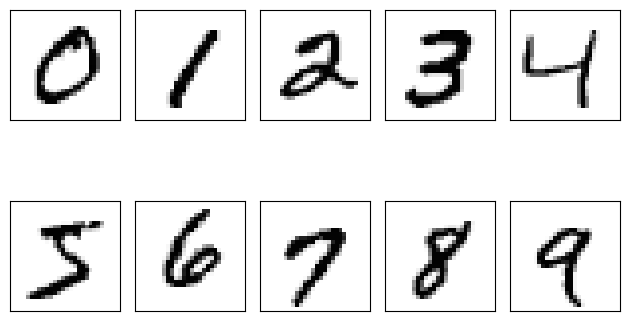

In [6]:
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(nrows=2, ncols=5,
                       sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

### Visualize 25 Versions of number '7':

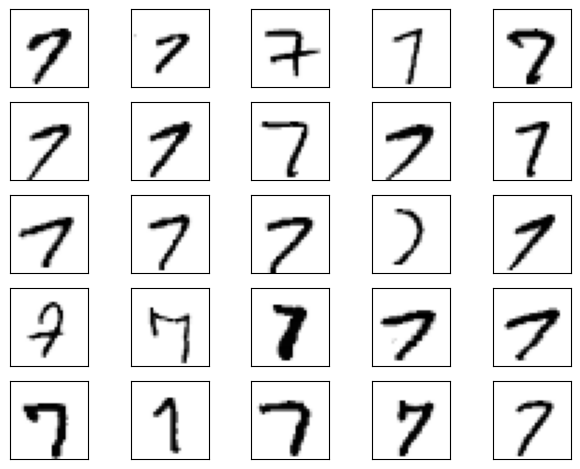

In [7]:
fig, ax = plt.subplots(nrows=5,
                       ncols=5,
                       sharex=True,
                       sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

## Split into Training, Validation, and Test Set:

In [8]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=10000, random_state=123, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)


# optional to free up some memory by deleting non-used arrays:
#del X_temp, y_temp, X, y

### Implementing a Multilayer Perceptron

In [9]:
import numpy as np

In [10]:
##############################
# Multilayer Perceptron Model
##############################

def sigmoid(z):                                        
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP:

    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()
        
        self.num_classes = num_classes
        
        # hidden
        rng = np.random.RandomState(random_seed)
        
        self.weight_h = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)
        
        # output
        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)
        
    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features] dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)

        # Output layer
        # input dim: [n_examples, n_hidden] dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):  
    
        #########################
        ### Output layer weights
        #########################
        
        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use
        
        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out # "delta (rule) placeholder"

        # gradient for output weights
        
        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h
        
        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)
        

        ###################################################################################        
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight
        ###################################################################################
        
        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out
        
        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)
        
        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative
        
        # [n_examples, n_features]
        d_z_h__d_w_h = x
        
        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

        return (d_loss__dw_out, d_loss__db_out, 
                d_loss__d_w_h, d_loss__d_b_h)

              




        

    

In [11]:
    model = NeuralNetMLP(num_features=28*28,
                         num_hidden=50,
                         num_classes=10)

### Coding the Neural Network Training Loop

#### Defining Data Loaders:

In [12]:
import numpy as np 

num_epochs = 50
minibatch_size = 100 

def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]

        yield X[batch_idx], y[batch_idx]

# Iterate over Training Epochs 
for i in range(num_epochs): 

    # iterate over minibatches 
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size)

    for X_train_mini, y_train_mini in minibatch_gen:

        break 
    break


print(X_train_mini.shape)
print(y_train_mini.shape)


    

(100, 784)
(100,)


## Defining a Function to Compute the Loss and Accuracy

In [13]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)

def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)
    
_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)

print(f'Initial Validation MSE: {mse:.1f}')
print(f'Initial Validation Accuracy: {acc*100:.1f}%')
    





Initial Validation MSE: 0.3
Initial Validation Accuracy: 9.8%


In [14]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)
        
    for i, (features, targets) in enumerate(minibatch_gen):

        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        
        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()
        
        num_examples += targets.shape[0]
        mse += loss

    mse = mse/(i+1)
    acc = correct_pred/num_examples
    return mse, acc

In [15]:
mse, acc = compute_mse_and_acc(model, X_valid, y_valid)
print(f'Initial Valid MSE: {mse:.1f}')
print(f'Initial Valid Accuracy: {acc*100:.1f}%')

Initial Valid MSE: 0.3
Initial Valid Accuracy: 9.8%


In [16]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1):
    
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []
    
    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:
            
            #### Compute outputs ####
            a_h, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out
        
        #### Epoch Logging ####        
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [17]:
np.random.seed(123)  ## For the Training Set Shuffling

epoch_loss, epoch_train_acc, epoch_valid_acc = train(
    model, X_train, y_train, X_valid, y_valid,
    num_epochs=50, learning_rate=0.1)
       

Epoch: 001/050 | Train MSE: 0.05 | Train Acc: 77.94% | Valid Acc: 77.60%
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 86.24% | Valid Acc: 85.76%
Epoch: 003/050 | Train MSE: 0.02 | Train Acc: 88.47% | Valid Acc: 88.24%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 89.83% | Valid Acc: 89.58%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 90.59% | Valid Acc: 90.32%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 91.00% | Valid Acc: 90.78%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 91.46% | Valid Acc: 91.10%
Epoch: 008/050 | Train MSE: 0.01 | Train Acc: 91.73% | Valid Acc: 91.36%
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 92.16% | Valid Acc: 91.84%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 92.36% | Valid Acc: 92.12%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 92.61% | Valid Acc: 92.50%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.80% | Valid Acc: 92.56%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.96% | Valid Acc: 92.64%
Epoch: 014/050 | Train MSE: 0.01 | Train Acc: 93.11

## Evaluating the Neural Network Performance

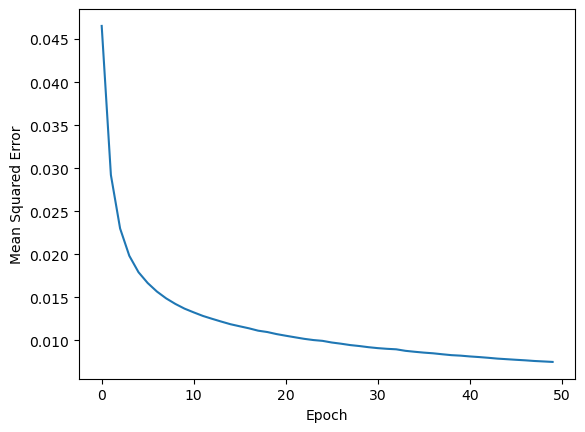

In [18]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel("Mean Squared Error")
plt.xlabel("Epoch")
plt.show()

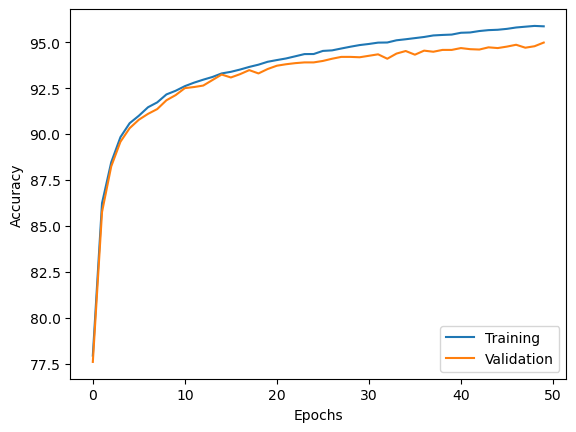

In [19]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.show()

In [20]:
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 94.74%


## Plot Failure Cases:

In [21]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]

_, probas = model.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)

misclassified_images = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

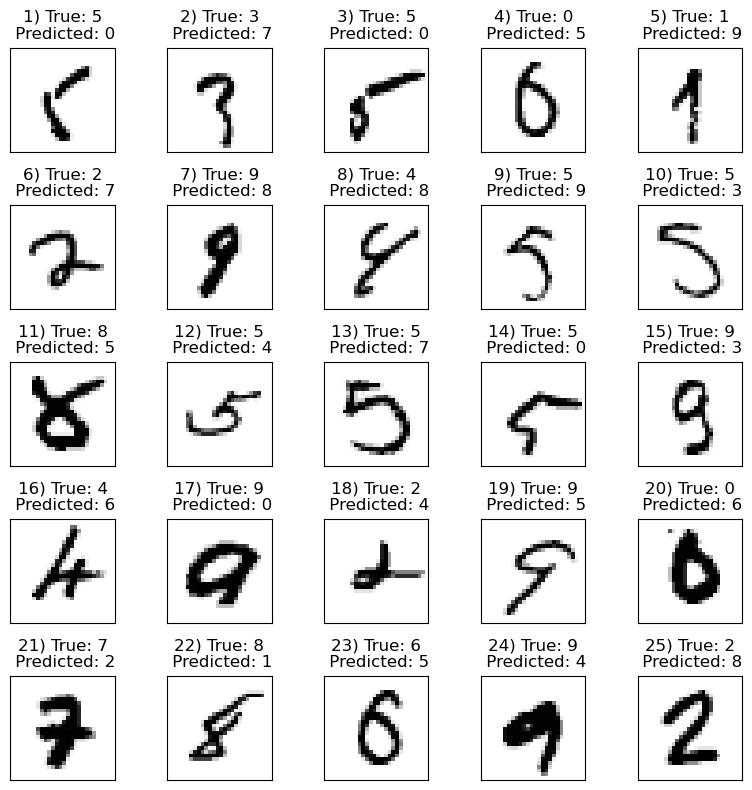

In [22]:
fig, ax = plt.subplots(nrows=5, ncols=5, 
                       sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

# Training an Artificial Neural Network

### Add notes,  functions etc
